Config loaded — 5 classes, window=2.5s, overlap=0.75
Model type : CNN_LSTM_DEEP

Hardcoded d_min (Q10 from EDA):
  LW: 0.08s (8 frames)
  RA: 0.12s (12 frames)
  RD: 0.12s (12 frames)
  SA: 0.12s (12 frames)
  SD: 0.08s (8 frames)
✓ Preprocessing & Windowing ready
✓ Models ready

Transition Mask (✓ allowed  ✗ forbidden)
          LW    SA    SD    RA    RD
    LW |   ✓     ✓     ✓     ✓     ✓ 
    SA |   ✓     ✓     ✗     ✗     ✗ 
    SD |   ✓     ✗     ✓     ✗     ✗ 
    RA |   ✓     ✗     ✗     ✓     ✗ 
    RD |   ✓     ✗     ✗     ✗     ✓ 
✓ ViterbiDecoder ready
✓ DurationFilter ready
✓ ModelLoader ready
✓ Sweepers ready
✓ Inferencer ready
✓ PostFilterEvaluator ready
Hardcoded d_min (frames): {0: 8, 3: 12, 4: 12, 1: 12, 2: 8}
Subjects : ['S1', 'S10', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Model    : CNN_LSTM_DEEP

  FOLD : S1
  Train : ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
  Val   : S10
  Test  : S1

  d_min estimation (Q10 of run lengths):
   State   N runs    M

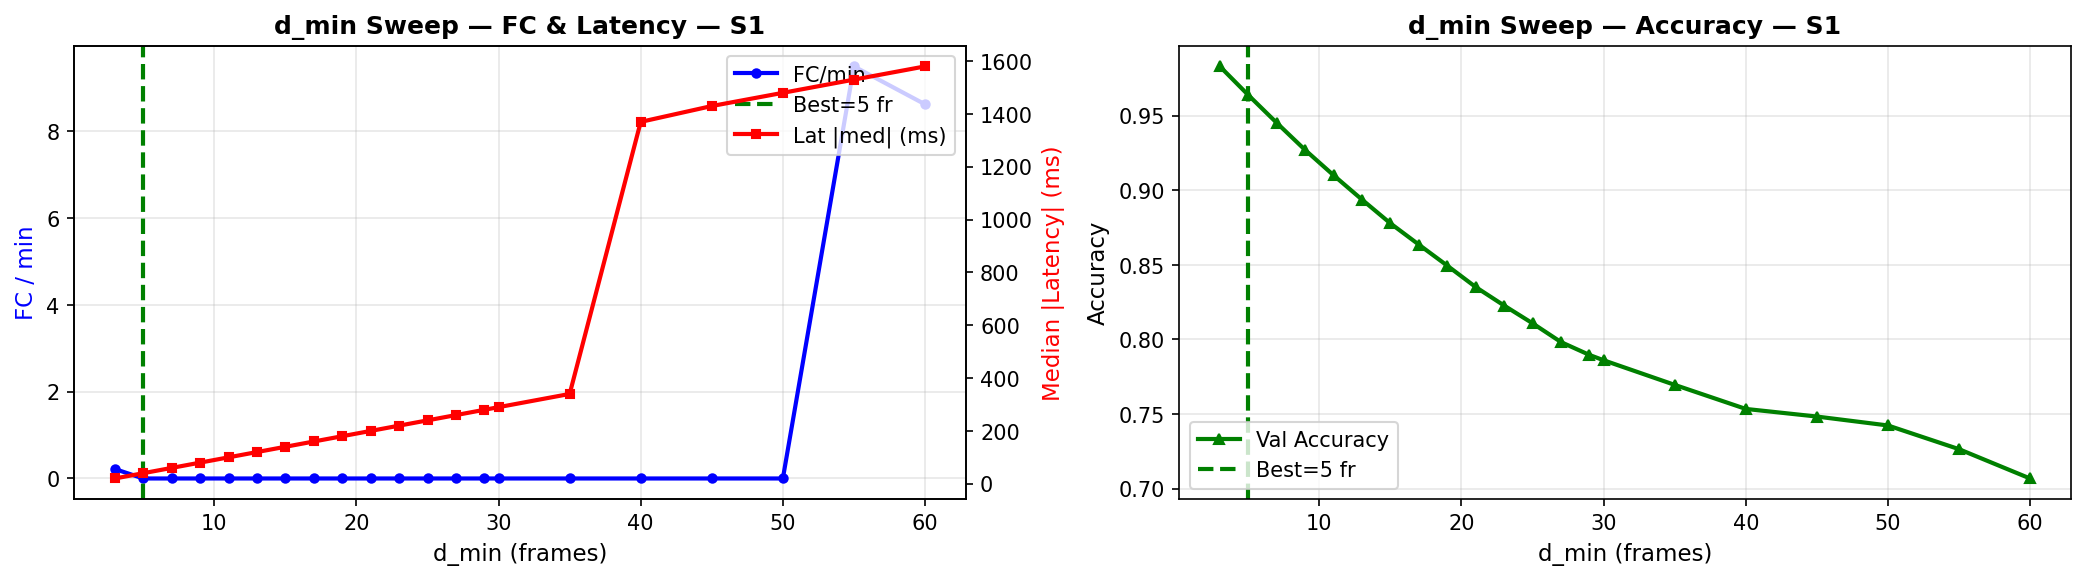


dmin_sweep_S10


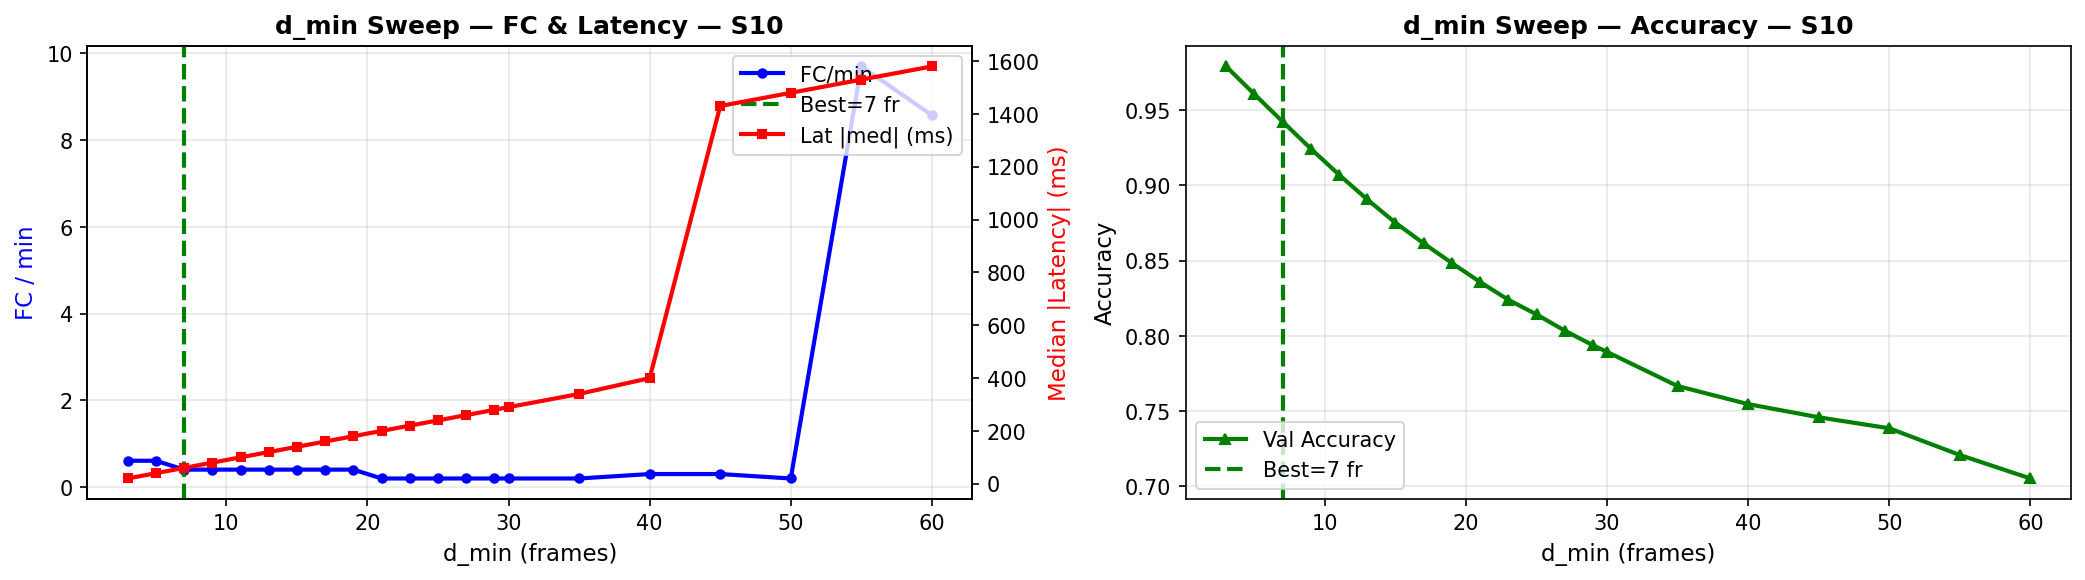


dmin_sweep_S2


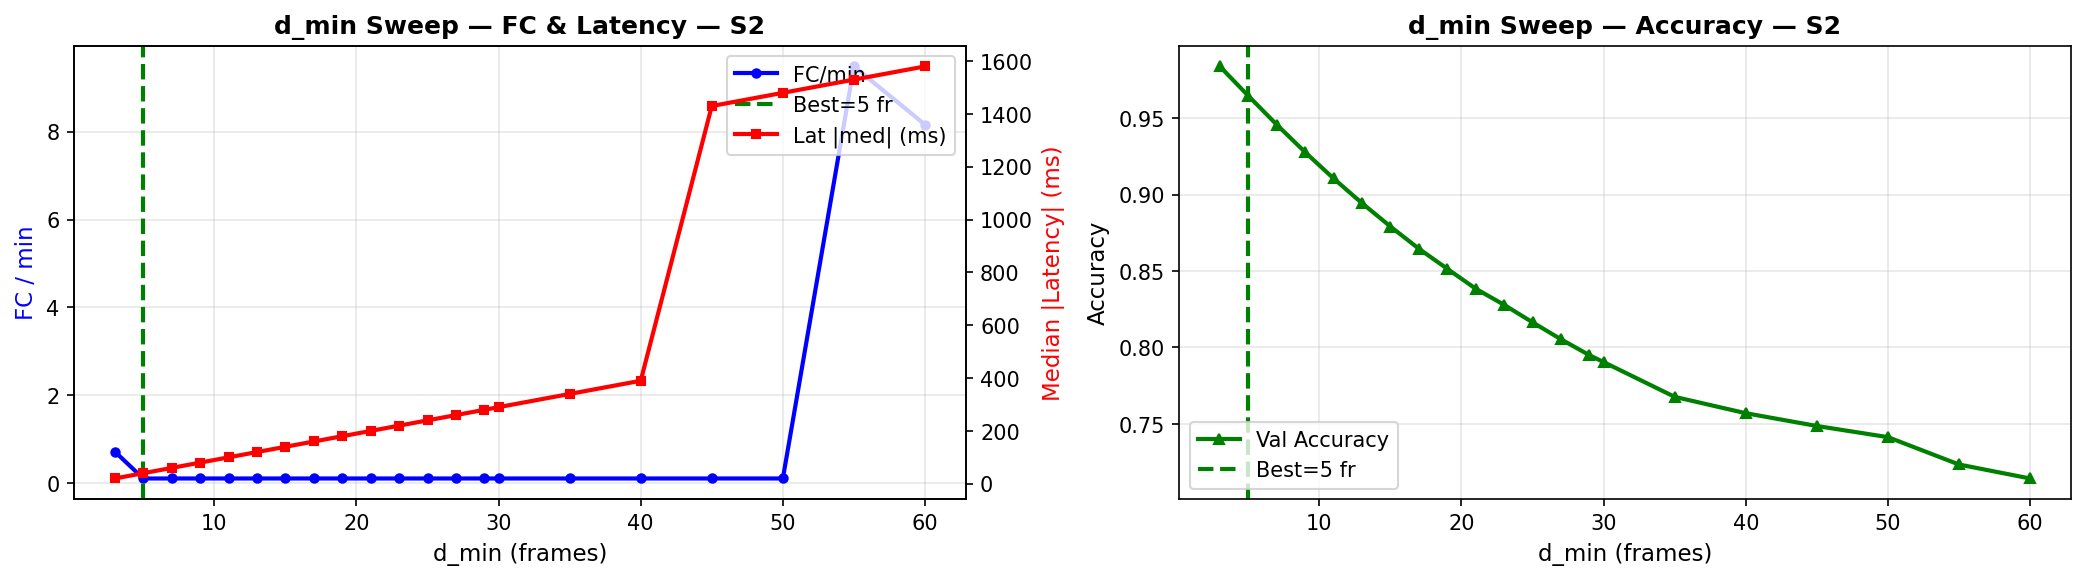


dmin_sweep_S3


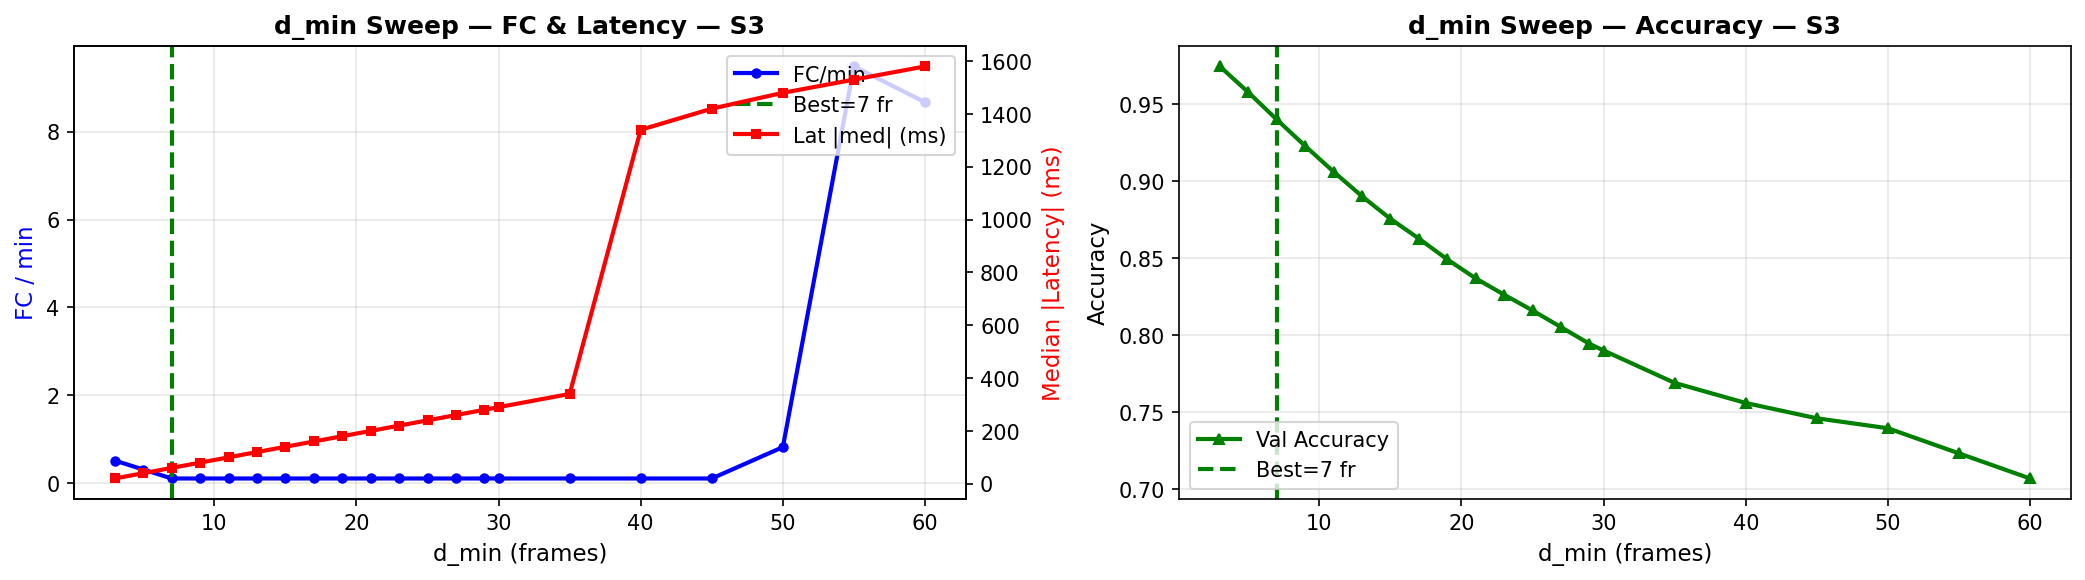


dmin_sweep_S4


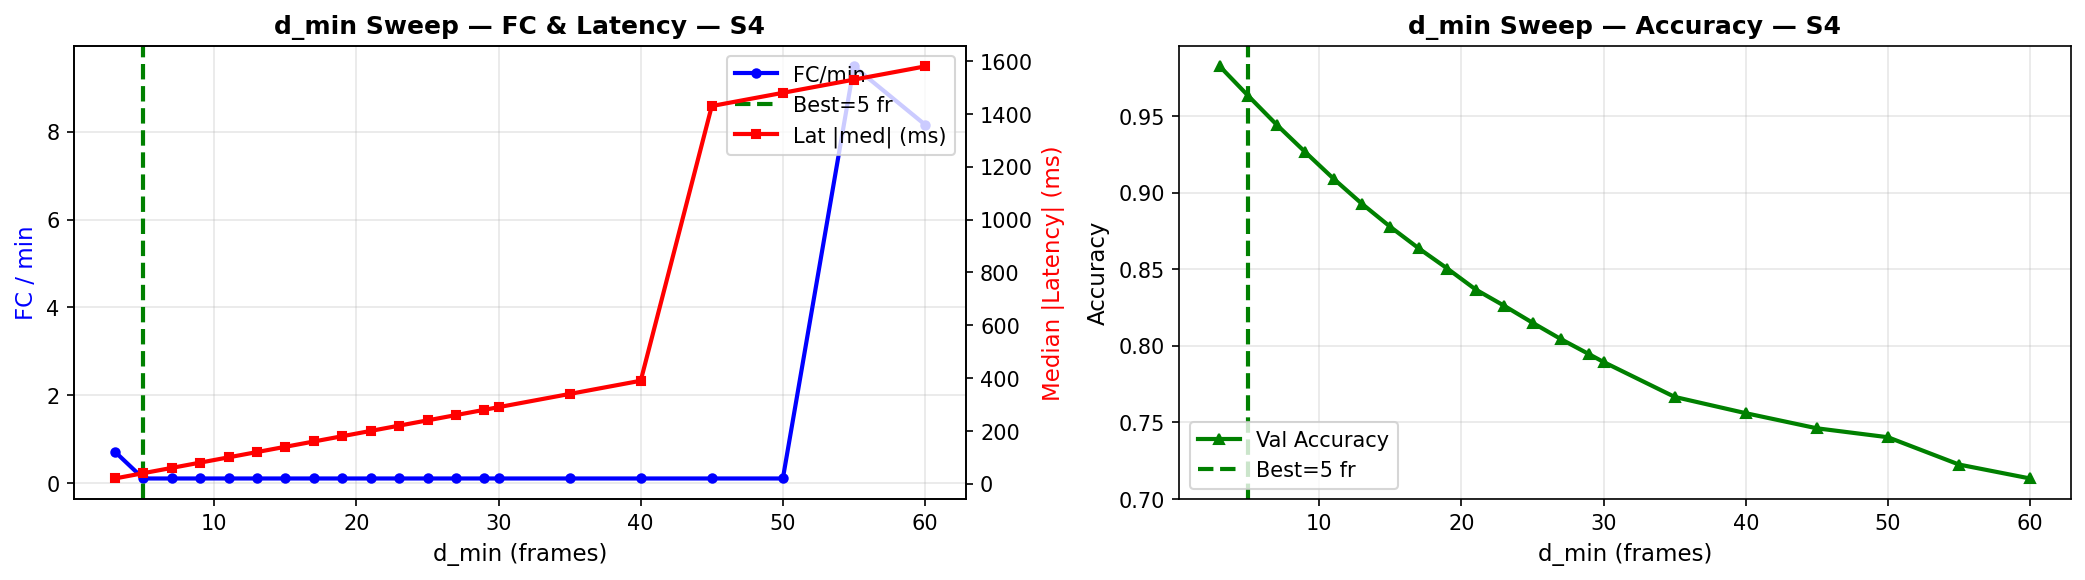


dmin_sweep_S5


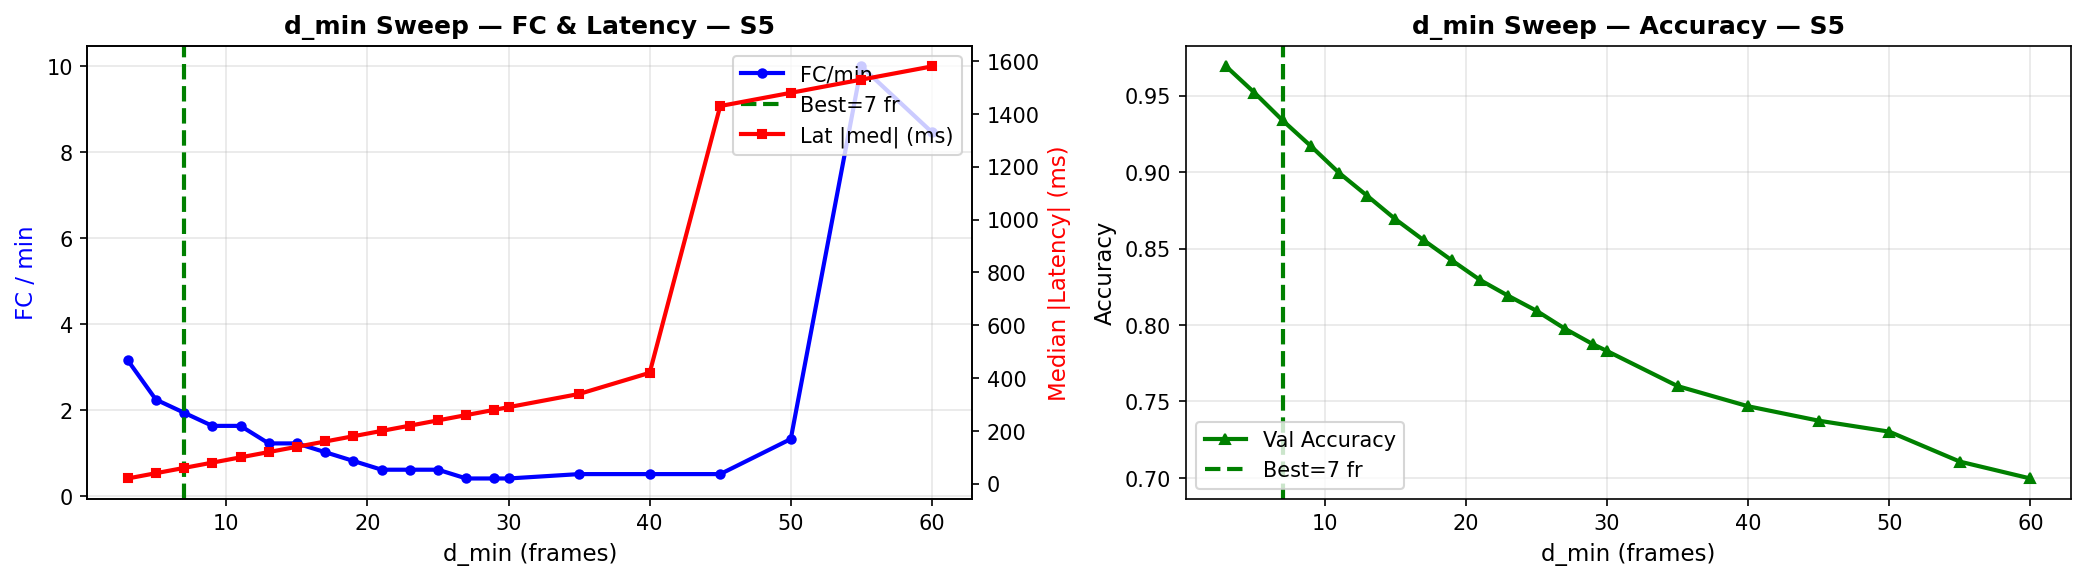


dmin_sweep_S6


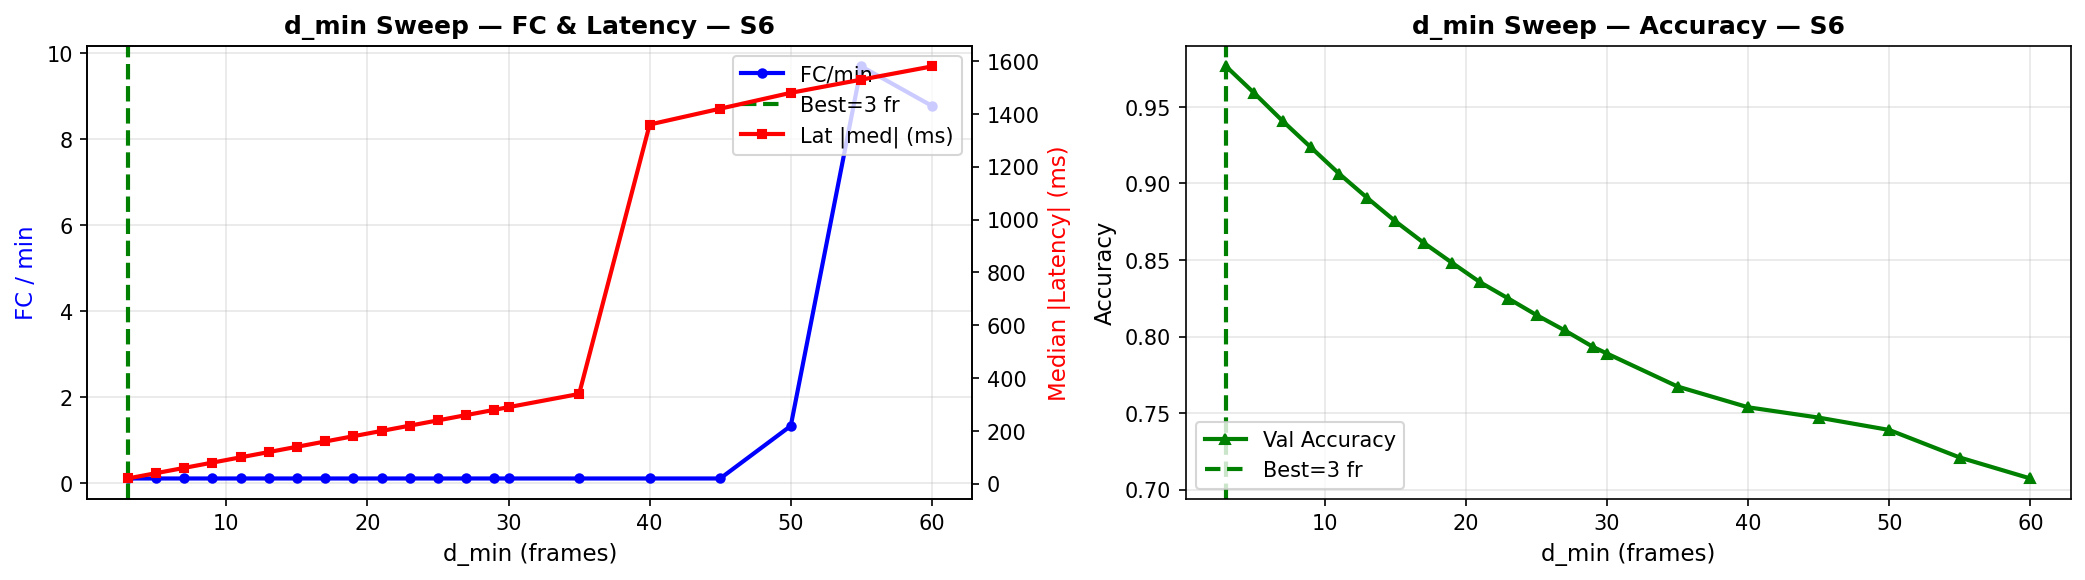


dmin_sweep_S7


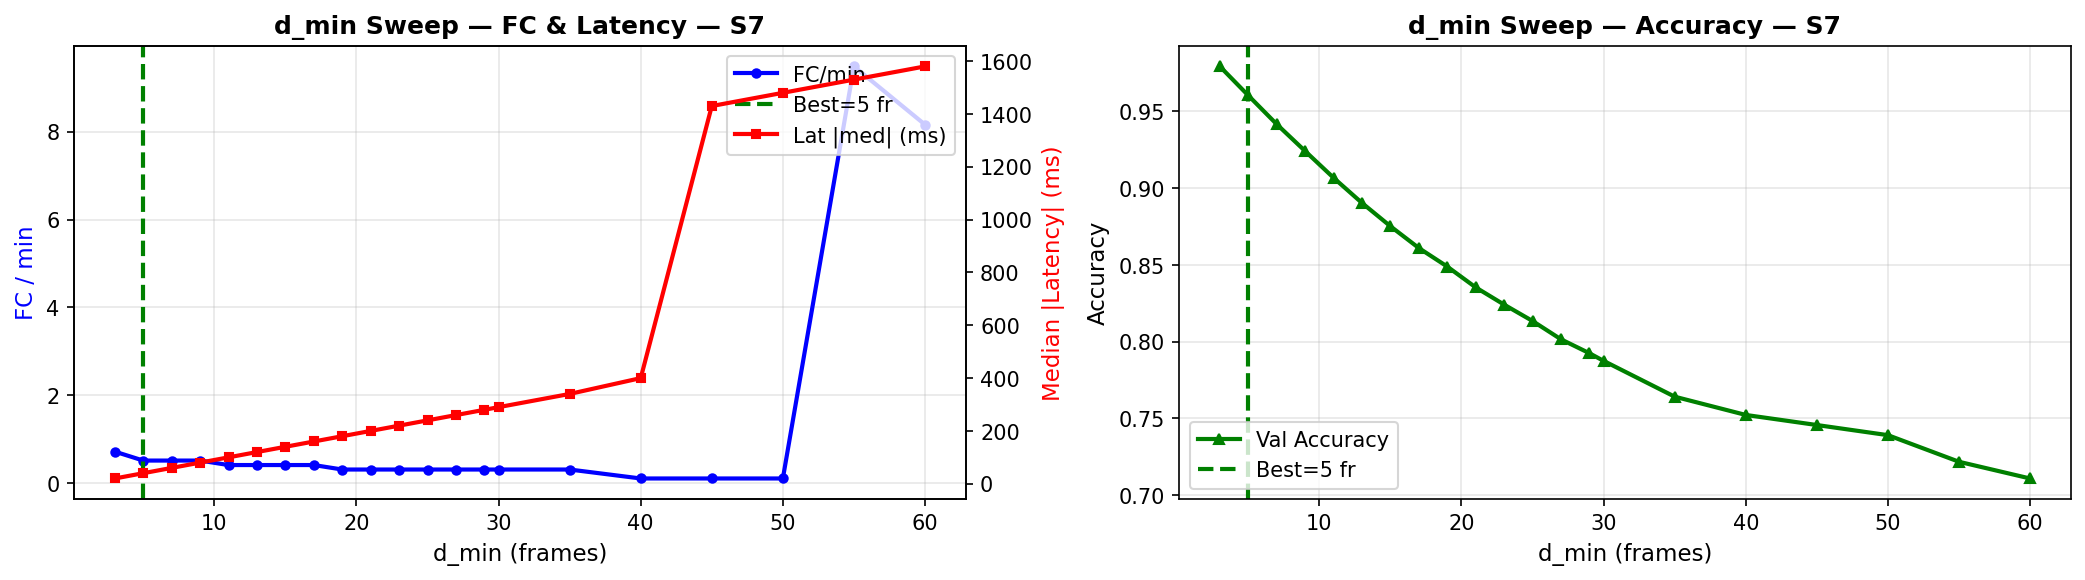


dmin_sweep_S8


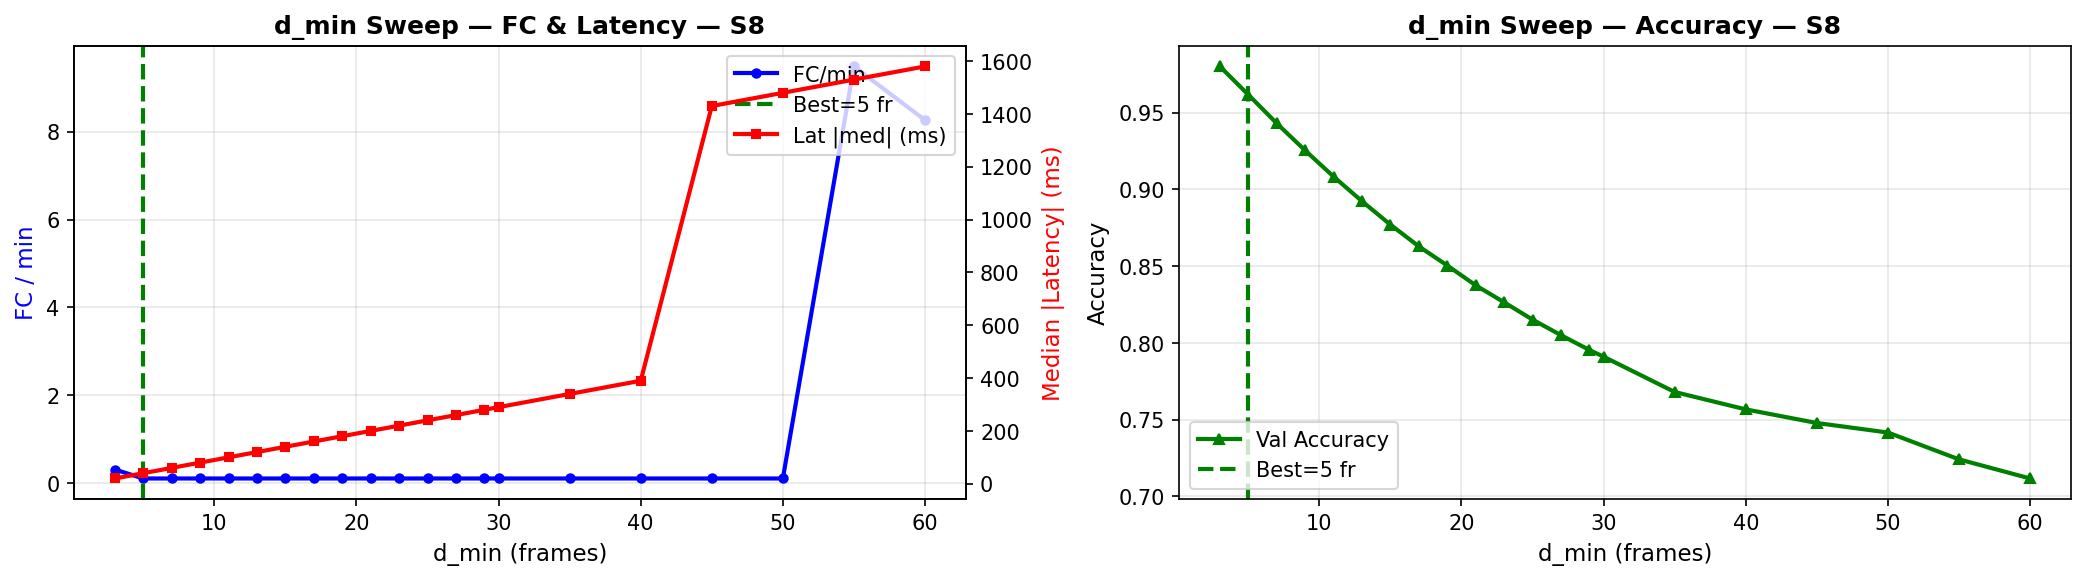


dmin_sweep_S9


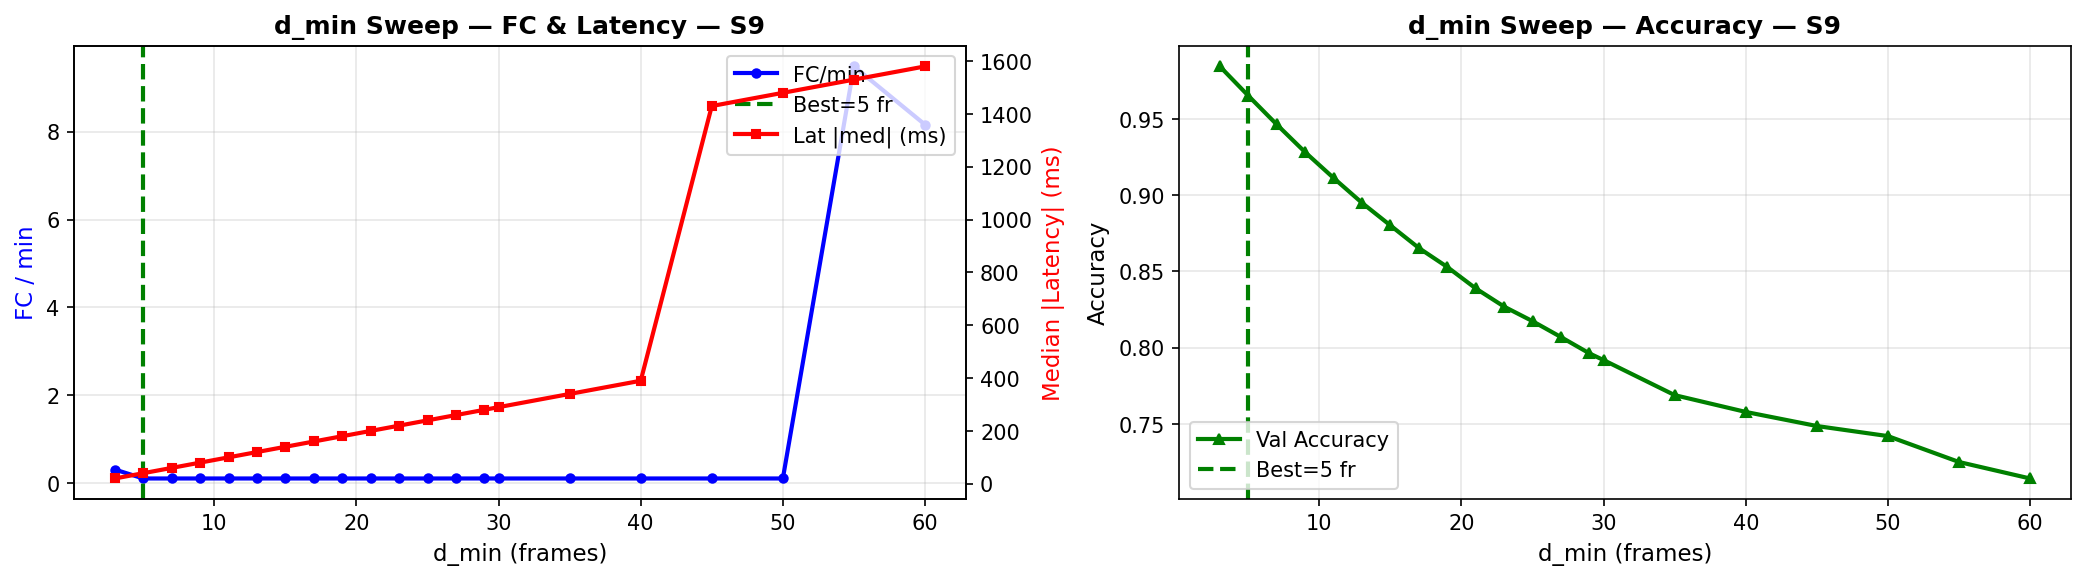


Method Comparison


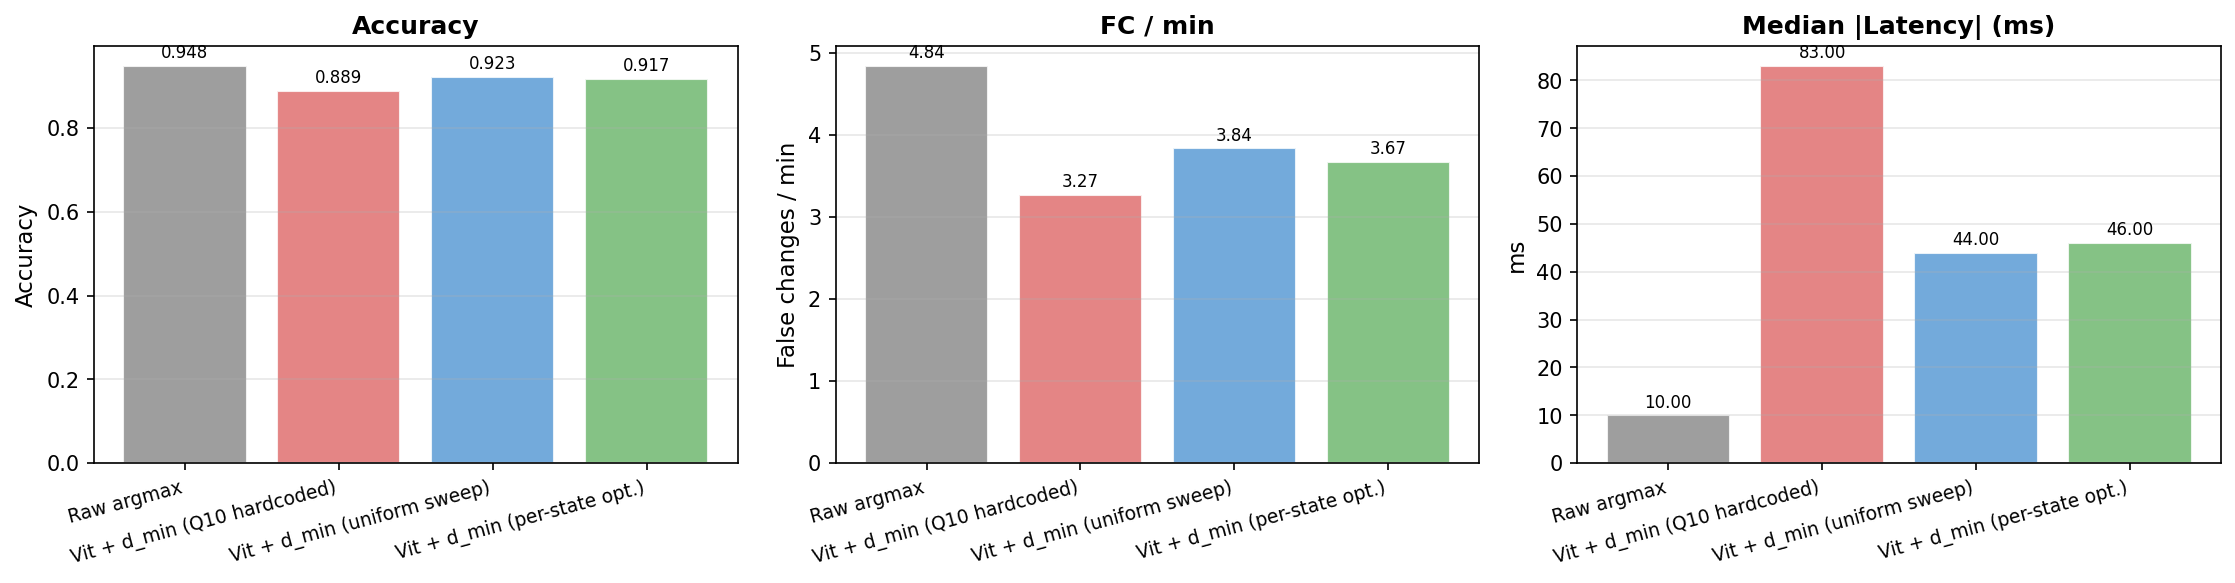


FULL REPORT

POST-FILTER EVALUATION REPORT — CNN_LSTM_DEEP
Generated : 2026-03-04 13:39:18
Model     : CNN_LSTM_DEEP
Subjects  : 10

HARDCODED d_min (Q10 from EDA)
  LW: 0.08s (8 frames)
  RA: 0.12s (12 frames)
  RD: 0.12s (12 frames)
  SA: 0.12s (12 frames)
  SD: 0.08s (8 frames)

SUMMARY — Mean over LOSO folds
  Method                                         Accuracy         F1   FC/min    |Lat|ms    Det%
  ------------------------------------------------------------------------------------------
  Raw argmax                                       0.9481     0.9457     4.84       10.0   94.1%
  Viterbi only                                     0.9482     0.9459     4.84       10.0   94.2%
  Vit + d_min (Q10 estimated)                      0.5504     0.5588     9.00     1957.0   28.3%
  Vit + d_min (Q10 hardcoded)                      0.8894     0.8872     3.27       83.0   86.9%
  Vit + d_min (uniform sweep)                      0.9227     0.9209     3.84       44.0   91.1%
  Vit + d_

In [1]:
# ============================================================
# S4 — Post-Filter Evaluation Notebook

# ── Cell 1 : Imports & paths ─────────────────────────────────
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import yaml
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.signal import butter, filtfilt
from typing import Dict, List, Tuple
from itertools import product
import warnings
warnings.filterwarnings('ignore')

CONFIG_PATH = '/kaggle/input/datasets/manelouchar/config/config.yaml'
DATA_DIR    = Path('/kaggle/input/datasets/manelouchar/processed')
MODELS_DIR  = Path('/kaggle/input/datasets/manelouchar/final-model/models_cnn_lstm_deep')
RESULTS_DIR = Path('/kaggle/working/results')
FIGURES_DIR = RESULTS_DIR / 'figures'

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

with open(CONFIG_PATH) as f:
    CFG = yaml.safe_load(f)

MODEL_TYPE  = 'cnn_lstm_deep'
SR          = 100          # Hz
NUM_CLASSES = 5
WINDOW_SIZE = 2.5
OVERLAP     = 0.75

# Hardcoded d_min from EDA (Q10 of per-class run-length distributions)
# Values derived from training data; used as a fixed baseline method.
DMIN_HARDCODED_SEC = {
    'LW': 0.08,   # 8 frames  = 80 ms
    'RA': 0.12,   # 12 frames = 120 ms
    'RD': 0.12,
    'SA': 0.12,
    'SD': 0.08,
}

print(f"Config loaded — {NUM_CLASSES} classes, window={WINDOW_SIZE}s, overlap={OVERLAP}")
print(f"Model type : {MODEL_TYPE.upper()}")
print(f"\nHardcoded d_min (Q10 from EDA):")
for state, val in DMIN_HARDCODED_SEC.items():
    print(f"  {state}: {val:.2f}s ({int(val*SR)} frames)")


# ── Cell 2 : Preprocessing & Windowing ───────────────────────

class IMUPreprocessor:
    """
    Two-step preprocessing pipeline used in all LOSO folds:
      1. 4th-order Butterworth low-pass at 25 Hz (preserves gait content < 20 Hz)
      2. Z-score normalisation fitted ONLY on the training fold to prevent leakage.
    """
    def __init__(self, method='zscore', use_lowpass=True,
                 cutoff_hz=25.0, sampling_rate=100, filter_order=4):
        self.method        = method
        self.use_lowpass   = use_lowpass
        self.cutoff_hz     = cutoff_hz
        self.sampling_rate = sampling_rate
        self.filter_order  = filter_order
        self.scalers: Dict[str, StandardScaler] = {}

    def _lowpass(self, X: np.ndarray) -> np.ndarray:
        if not self.use_lowpass:
            return X
        nyq  = self.sampling_rate / 2.0
        b, a = butter(self.filter_order, self.cutoff_hz / nyq, btype='low')
        return np.stack(
            [filtfilt(b, a, X[:, i]) for i in range(X.shape[1])], axis=1
        )

    def fit(self, X: np.ndarray, subject_id: str) -> None:
        X = self._lowpass(X)
        sc = StandardScaler()
        sc.fit(X)
        self.scalers[subject_id] = sc

    def transform(self, X: np.ndarray, subject_id: str) -> np.ndarray:
        X = self._lowpass(X)
        return self.scalers[subject_id].transform(X)


class WindowGenerator:
    """
    Sliding-window segmentation with per-frame label retention
    (many-to-many: each window yields W labels).
    """
    def __init__(self, window_size: float = 2.5,
                 overlap: float = 0.75, sampling_rate: int = 100):
        self.win  = int(window_size * sampling_rate)
        self.step = max(1, int(self.win * (1 - overlap)))

    def create_windows(self, X: np.ndarray,
                       y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        wins, labs = [], []
        for start in range(0, len(X) - self.win + 1, self.step):
            wins.append(X[start:start + self.win])
            labs.append(y[start:start + self.win])
        return np.array(wins, dtype=np.float32), np.array(labs, dtype=np.int64)


print("✓ Preprocessing & Windowing ready")


# ── Cell 3 : Models ───────────────────────────────────────────
# (Unchanged from original — architecturally correct)

class LSTMClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 256,
                 num_layers: int = 2, num_classes: int = 5,
                 dropout: float = 0.2, bidirectional: bool = False):
        super().__init__()
        self.hidden_size    = hidden_size
        self.num_layers     = num_layers
        self.bidirectional  = bidirectional
        self.num_directions = 2 if bidirectional else 1
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional, batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size * self.num_directions, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        out    = self.dropout(out)
        B, T, H = out.shape
        return self.fc(out.reshape(-1, H)).reshape(B, T, -1)


class CNNLSTMClassifier(nn.Module):
    def __init__(self, input_size: int, num_classes: int = 5,
                 cnn_channels: List[int] = [64, 128, 128],
                 kernel_sizes:  List[int] = [5, 5, 3],
                 hidden_size: int = 256, num_layers: int = 2,
                 dropout: float = 0.2, bidirectional: bool = True):
        super().__init__()
        self.hidden_size    = hidden_size
        self.num_directions = 2 if bidirectional else 1
        layers, in_ch = [], input_size
        for out_ch, ks in zip(cnn_channels, kernel_sizes):
            layers += [nn.Conv1d(in_ch, out_ch, ks, padding=ks//2),
                       nn.BatchNorm1d(out_ch), nn.ReLU(),
                       nn.Dropout(dropout * 0.5)]
            in_ch = out_ch
        self.cnn  = nn.Sequential(*layers)
        self.lstm = nn.LSTM(in_ch, hidden_size, num_layers,
                            dropout=dropout if num_layers > 1 else 0.0,
                            bidirectional=bidirectional, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size * self.num_directions, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape
        z       = self.cnn(x.transpose(1, 2)).transpose(1, 2)
        h, _    = self.lstm(z)
        h       = self.drop(h)
        return self.fc(h.reshape(-1, self.hidden_size * self.num_directions)).reshape(B, T, -1)


class CNNLSTMClassifierDeep(nn.Module):
    """
    CNN–BiLSTM with intermediate max-pooling and linear interpolation
    to restore full temporal resolution before the classification head.
    """
    def __init__(self, input_size: int, num_classes: int = 5,
                 cnn_channels: List[int] = [64, 128, 256],
                 kernel_sizes:  List[int] = [7, 5, 3],
                 pool_sizes:    List[int] = [2, 2, 1],
                 hidden_size: int = 256, num_layers: int = 2,
                 dropout: float = 0.2, bidirectional: bool = True):
        super().__init__()
        self.hidden_size    = hidden_size
        self.num_directions = 2 if bidirectional else 1
        layers, in_ch = [], input_size
        for out_ch, ks, ps in zip(cnn_channels, kernel_sizes, pool_sizes):
            layers += [nn.Conv1d(in_ch, out_ch, ks, padding=ks//2),
                       nn.BatchNorm1d(out_ch), nn.ReLU(),
                       nn.MaxPool1d(ps) if ps > 1 else nn.Identity(),
                       nn.Dropout(dropout * 0.5)]
            in_ch = out_ch
        self.cnn             = nn.Sequential(*layers)
        self.upsample_factor = int(np.prod(pool_sizes))
        self.lstm = nn.LSTM(in_ch, hidden_size, num_layers,
                            dropout=dropout if num_layers > 1 else 0.0,
                            bidirectional=bidirectional, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size * self.num_directions, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _  = x.shape
        z        = self.cnn(x.transpose(1, 2)).transpose(1, 2)
        h, _     = self.lstm(z)
        h        = self.drop(h)
        if self.upsample_factor > 1:
            h = nn.functional.interpolate(
                h.transpose(1, 2), size=T, mode='linear', align_corners=False
            ).transpose(1, 2)
        return self.fc(h.reshape(-1, self.hidden_size * self.num_directions)).reshape(B, T, -1)


print("✓ Models ready")


# ── Cell 4 : Transition mask ──────────────────────────────────

STATES    = ['LW', 'SA', 'SD', 'RA', 'RD']
STATE2IDX = {s: i for i, s in enumerate(STATES)}

# Biomechanically valid transitions:
# Stair/ramp modes can only transition through level-walking (LW).
_ALLOWED = np.array([
    [1, 1, 1, 1, 1],   # from LW → all allowed
    [1, 1, 0, 0, 0],   # from SA → only LW or stay
    [1, 0, 1, 0, 0],   # from SD → only LW or stay
    [1, 0, 0, 1, 0],   # from RA → only LW or stay
    [1, 0, 0, 0, 1],   # from RD → only LW or stay
], dtype=bool)

# Log-domain: 0 for allowed, -inf for forbidden (hard constraint)
LOG_TRANS = np.where(_ALLOWED, 0.0, -np.inf)

def print_transition_mask() -> None:
    print("\nTransition Mask (✓ allowed  ✗ forbidden)")
    print("        " + "  ".join(f"{s:>4}" for s in STATES))
    for i, row in enumerate(_ALLOWED):
        cells = "  ".join("  ✓ " if v else "  ✗ " for v in row)
        print(f"  {STATES[i]:>4} | {cells}")

print_transition_mask()


# ── Cell 5 : ViterbiDecoder ───────────────────────────────────

class ViterbiDecoder:
    """
    Constrained Viterbi decoder.

    Finds the globally optimal state sequence that maximises
    the sum of log-softmax emission scores subject to the
    hard transition constraint encoded in LOG_TRANS.

    Complexity: O(T × K²)
    """

    def decode(self, logits: np.ndarray) -> np.ndarray:
        """
        Args:
            logits: (T, C) raw classifier outputs
        Returns:
            path: (T,) integer class indices
        """
        T, C = logits.shape
        lp   = self._log_softmax(logits)          # (T, C)
        dp   = np.full((T, C), -np.inf)
        bp   = np.zeros((T, C), dtype=int)
        dp[0] = lp[0]

        for t in range(1, T):
            # scores[i, j] = dp[t-1, i] + log_trans[i, j]
            scores = dp[t-1, :, None] + LOG_TRANS  # (C, C)
            bp[t]  = scores.argmax(axis=0)          # best predecessor
            dp[t]  = scores.max(axis=0) + lp[t]

        # Backtrack
        path      = np.empty(T, dtype=int)
        path[T-1] = dp[T-1].argmax()
        for t in range(T-2, -1, -1):
            path[t] = bp[t+1, path[t+1]]
        return path

    @staticmethod
    def argmax_baseline(logits: np.ndarray) -> np.ndarray:
        """Greedy frame-wise argmax — no temporal constraint."""
        return np.argmax(logits, axis=-1)

    @staticmethod
    def _log_softmax(x: np.ndarray) -> np.ndarray:
        x = x - x.max(axis=-1, keepdims=True)
        return x - np.log(np.exp(x).sum(axis=-1, keepdims=True))


print("✓ ViterbiDecoder ready")


# ── Cell 6 : DurationFilter ───────────────────────────────────

class DurationFilter:
    """
    Minimum-duration confirmation filter.

    Accepts a new locomotion mode only after d_min[state] consecutive
    frames of agreement, encoding the physiological constraint that
    a genuine mode change requires a minimum biomechanical commitment
    time before it is mechanically established.

    Per-state d_min values allow stair/ramp transitions (which develop
    over longer biomechanical timescales) to require longer confirmation
    than level-walking transitions.
    """

    def __init__(self, d_min: Dict[int, int], sampling_rate: int = SR):
        self.d_min = d_min
        self.sr    = sampling_rate

    # ── Core filter ──────────────────────────────────────────

    def apply(self, predictions: np.ndarray) -> np.ndarray:
        """
        Args:
            predictions: (T,) integer label sequence (e.g. from Viterbi)
        Returns:
            confirmed: (T,) filtered label sequence
        """
        T            = len(predictions)
        confirmed    = np.empty(T, dtype=int)
        cur_state    = int(predictions[0])
        cand_state   = int(predictions[0])
        cand_count   = 1
        confirmed[0] = cur_state

        for t in range(1, T):
            pred = int(predictions[t])
            if pred == cand_state:
                cand_count += 1
            else:
                cand_state = pred
                cand_count = 1

            # Promote candidate to confirmed state once threshold met
            if (cand_state != cur_state and
                    cand_count >= self.d_min.get(cand_state, 1)):
                cur_state = cand_state
            confirmed[t] = cur_state
        return confirmed

    # ── d_min estimation from training labels ────────────────

    @staticmethod
    def estimate_from_labels(labels: np.ndarray,
                             subject_boundaries: List[int],
                             num_classes: int,
                             quantile: float = 0.10,
                             sampling_rate: int = SR) -> Dict[int, int]:
        """
        Estimate d_min per class from run-length distributions of the
        TRAINING labels.

        CORRECTION vs. original: subject boundary frames are stripped
        before computing run lengths to avoid artefactual short runs
        created where two subjects are concatenated.

        Args:
            labels:             (N,) concatenated training labels
            subject_boundaries: list of indices where subject changes occur
            num_classes:        K
            quantile:           Q10 = conservative lower bound, avoids
                                over-smoothing while suppressing short noise
            sampling_rate:      Hz

        Returns:
            d_min: {class_idx: min_frames}
        """
        boundary_set = set(subject_boundaries)

        # Run-length encoding, skipping boundary transitions
        runs: List[Tuple[int, int]] = []
        cur, cnt = int(labels[0]), 1
        for t in range(1, len(labels)):
            if t in boundary_set:
                # flush current run, do not create boundary run
                runs.append((cur, cnt))
                cur, cnt = int(labels[t]), 1
            elif int(labels[t]) == cur:
                cnt += 1
            else:
                runs.append((cur, cnt))
                cur, cnt = int(labels[t]), 1
        runs.append((cur, cnt))

        lengths: Dict[int, List[int]] = {c: [] for c in range(num_classes)}
        for state, length in runs:
            if 0 <= state < num_classes:
                lengths[state].append(length)

        d_min: Dict[int, int] = {}
        print(f"\n  d_min estimation (Q{quantile*100:.0f} of run lengths):")
        print(f"  {'State':>6}  {'N runs':>7}  {'Median':>8}  "
              f"{'d_min(fr)':>10}  {'d_min(ms)':>10}")
        print("  " + "-" * 52)
        for c in range(num_classes):
            lens = lengths[c]
            if not lens:
                d_min[c] = 1
                continue
            med      = int(np.median(lens))
            qval     = max(int(np.quantile(lens, quantile)), 1)
            d_min[c] = qval
            print(f"  {STATES[c]:>6}  {len(lens):>7}  {med:>8}  "
                  f"{qval:>10}  {qval/sampling_rate*1000:>9.0f}ms")
        return d_min

    # ── FC/min ───────────────────────────────────────────────

    def false_changes_per_min(self,
                              predictions: np.ndarray,
                              ground_truth: np.ndarray,
                              tolerance_sec: float = 0.5) -> float:
        """
        False Changes per minute.

        Definition (publication standard):
            A predicted transition at time t is FALSE if there is no
            ground-truth transition within ±tolerance_sec of t.

        Normalisation: per minute of RECORDING TIME (not per transition),
        consistent with Moon et al. (2025) and Young et al. (2014).

        Args:
            predictions:    (T,) predicted sequence
            ground_truth:   (T,) ground-truth sequence
            tolerance_sec:  half-window in seconds for GT matching
                            (default 0.5 s = 50 frames at 100 Hz)
        Returns:
            fc_per_min: float ≥ 0
        """
        T             = len(predictions)
        duration_min  = T / self.sr / 60.0
        tolerance_fr  = int(tolerance_sec * self.sr)

        # Ground-truth transition times (frame indices)
        gt_trans = {t for t in range(1, T)
                    if ground_truth[t] != ground_truth[t-1]}

        false_count = 0
        for t in range(1, T):
            if predictions[t] != predictions[t-1]:
                # False iff no GT transition within ±tolerance_fr
                if not any(abs(t - tt) <= tolerance_fr for tt in gt_trans):
                    false_count += 1

        return false_count / duration_min if duration_min > 0 else 0.0

    # ── Transition latency ───────────────────────────────────

    def transition_latency(self,
                           predictions: np.ndarray,
                           ground_truth: np.ndarray,
                           max_window_sec: float = 3.0) -> Dict[str, float]:
        """
        Publication-grade transition detection latency.

        For each ground-truth transition (s_from → s_to) at frame t_true,
        find the closest predicted transition of the SAME type (same
        s_from and s_to pair) within ±max_window_sec.

        Latency (signed) = t_pred − t_true
            > 0 : delayed detection  (predicted AFTER ground truth)
            < 0 : early detection    (predicted BEFORE ground truth)

        The paper table reports:
            median_abs_ms  — median of |latency| in ms  (always ≥ 0)
            median_signed_ms — median of signed latency  (shows bias)

        One-to-one matching: each predicted transition is consumed once.

        Returns dict with keys:
            median_abs_ms, median_signed_ms,
            mean_abs_ms,   mean_signed_ms,
            iqr_abs_ms,    p25_abs_ms,  p75_abs_ms,
            n_detected,    n_missed,    detection_rate
        """
        T          = len(ground_truth)
        max_frames = int(self.sr * max_window_sec)

        # Extract ground-truth transitions
        true_trans: List[Tuple[int, int, int]] = []
        for t in range(1, T):
            if ground_truth[t] != ground_truth[t-1]:
                true_trans.append((t, int(ground_truth[t-1]), int(ground_truth[t])))

        # Extract predicted transitions
        pred_trans: List[Tuple[int, int, int]] = []
        for t in range(1, T):
            if predictions[t] != predictions[t-1]:
                pred_trans.append((t, int(predictions[t-1]), int(predictions[t])))

        used_pred: set = set()
        latencies_fr: List[int] = []
        missed = 0

        for t_true, s_from, s_to in true_trans:
            best_idx   = None
            best_dist  = None
            best_delay = None

            for i, (t_pred, p_from, p_to) in enumerate(pred_trans):
                if i in used_pred:
                    continue
                # Strict type match — prevents cross-type confusion
                if p_from != s_from or p_to != s_to:
                    continue
                delay = t_pred - t_true
                if abs(delay) <= max_frames:
                    if best_dist is None or abs(delay) < best_dist:
                        best_dist  = abs(delay)
                        best_delay = delay
                        best_idx   = i

            if best_idx is not None:
                latencies_fr.append(best_delay)
                used_pred.add(best_idx)
            else:
                missed += 1

        n_true = len(true_trans)
        n_det  = len(latencies_fr)

        if n_det == 0:
            nan = float('nan')
            return dict(median_abs_ms=nan, median_signed_ms=nan,
                        mean_abs_ms=nan,   mean_signed_ms=nan,
                        iqr_abs_ms=nan,    p25_abs_ms=nan, p75_abs_ms=nan,
                        n_detected=0, n_missed=missed,
                        detection_rate=0.0)

        lat_fr  = np.array(latencies_fr, dtype=float)
        lat_ms  = lat_fr / self.sr * 1000.0
        abs_ms  = np.abs(lat_ms)
        p25, p75 = np.percentile(abs_ms, [25, 75])

        return dict(
            median_abs_ms    = float(np.median(abs_ms)),
            median_signed_ms = float(np.median(lat_ms)),
            mean_abs_ms      = float(np.mean(abs_ms)),
            mean_signed_ms   = float(np.mean(lat_ms)),
            iqr_abs_ms       = float(p75 - p25),
            p25_abs_ms       = float(p25),
            p75_abs_ms       = float(p75),
            n_detected       = n_det,
            n_missed         = missed,
            detection_rate   = n_det / (n_true + 1e-9),
        )

    # ── Diagnostic breakdown ─────────────────────────────────

    def fc_breakdown(self,
                     predictions: np.ndarray,
                     ground_truth: np.ndarray,
                     tolerance_sec: float = 0.5) -> dict:
        """
        Diagnostic decomposition of predicted transitions into:
            matched   : TP transitions (near a GT event)
            false     : FP transitions (no nearby GT event)
        """
        T            = len(predictions)
        tolerance_fr = int(tolerance_sec * self.sr)
        duration_min = T / self.sr / 60.0

        gt_trans   = {t for t in range(1, T)
                      if ground_truth[t] != ground_truth[t-1]}
        pred_trans = [t for t in range(1, T)
                      if predictions[t] != predictions[t-1]]

        false_list, matched_list = [], []
        for t in pred_trans:
            if any(abs(t - tt) <= tolerance_fr for tt in gt_trans):
                matched_list.append(t)
            else:
                false_list.append(t)

        fc_per_min = len(false_list) / duration_min if duration_min > 0 else 0.0
        return dict(
            n_pred_trans   = len(pred_trans),
            n_gt_trans     = len(gt_trans),
            n_matched      = len(matched_list),
            n_false        = len(false_list),
            fc_per_min     = fc_per_min,
            duration_min   = duration_min,
        )


print("✓ DurationFilter ready")


# ── Cell 7 : ModelLoader ─────────────────────────────────────

class ModelLoader:
    _DEFAULTS = {
        'lstm': dict(
            hidden_size=256, num_layers=2, dropout=0.2, bidirectional=False
        ),
        'cnn_lstm': dict(
            cnn_channels=[64, 128, 128], kernel_sizes=[5, 5, 3],
            hidden_size=256, num_layers=2, dropout=0.2, bidirectional=True
        ),
        'cnn_lstm_deep': dict(
            cnn_channels=[64, 128, 256], kernel_sizes=[7, 5, 3],
            pool_sizes=[2, 2, 1],
            hidden_size=256, num_layers=2, dropout=0.2, bidirectional=True
        ),
    }

    def __init__(self, models_dir: Path, model_type: str, cfg: dict):
        self.models_dir = models_dir
        self.model_type = model_type
        self.overrides  = cfg.get('model', {})

    def load(self, test_subject: str, input_size: int,
             num_classes: int) -> nn.Module:
        ckpt = self.models_dir / f'cnn_lstm_deep_{test_subject}.pth'
        if not ckpt.exists():
            ckpt = self.models_dir / f'model_{self.model_type}_{test_subject}.pth'
        print(f"  Loading: {ckpt.name}")
        state = torch.load(ckpt, weights_only=False, map_location='cpu')
        model = self._build(input_size, num_classes)
        model.load_state_dict(state['model_state_dict'])
        model.eval()
        return model

    def _build(self, input_size: int, num_classes: int) -> nn.Module:
        kw = {**self._DEFAULTS[self.model_type], **self.overrides}
        if self.model_type == 'lstm':
            return LSTMClassifier(input_size, num_classes=num_classes, **kw)
        if self.model_type == 'cnn_lstm':
            return CNNLSTMClassifier(input_size, num_classes=num_classes, **kw)
        if self.model_type == 'cnn_lstm_deep':
            return CNNLSTMClassifierDeep(input_size, num_classes=num_classes, **kw)
        raise ValueError(f"Unknown model_type: {self.model_type}")


print("✓ ModelLoader ready")


# ── Cell 8 : Sweepers ─────────────────────────────────────────

class DMinSweeper:
    """
    Uniform d_min sweep: a single threshold shared across all states.

    Optimisation objective (constrained):
        minimise  2 × FC/min + Lat_median_abs_ms / 500
        subject to  Acc ≥ Acc_raw − ε   (ε = 0.02)

    The weight of 2 reflects the higher clinical cost of false actuations
    relative to detection latency in safety-critical control.
    Performed on the VALIDATION subject to avoid test leakage.
    """
    def __init__(self, dmin_range, sampling_rate: int = SR):
        self.dmin_range = list(dmin_range)
        self.sr         = sampling_rate

    def sweep(self,
              vit_preds_val:  np.ndarray,
              gt_val:         np.ndarray,
              raw_acc_val:    float,
              eps:            float = 0.02) -> dict:
        """
        All computations are on the VALIDATION split.

        Args:
            vit_preds_val : Viterbi predictions on val subject (T,)
            gt_val        : ground-truth labels on val subject (T,)
            raw_acc_val   : raw argmax accuracy on val subject
            eps           : max acceptable accuracy drop

        Returns:
            dict with sweep curves and best_dmin
        """
        acc_list, fc_list, lat_list = [], [], []

        for d in self.dmin_range:
            filt  = DurationFilter({c: d for c in range(NUM_CLASSES)}, self.sr)
            preds = filt.apply(vit_preds_val)

            acc = accuracy_score(gt_val, preds)
            fc  = filt.false_changes_per_min(preds, gt_val)
            lat = filt.transition_latency(preds, gt_val)
            lat_ms = lat['median_abs_ms'] if not np.isnan(lat['median_abs_ms']) else 0.0

            acc_list.append(acc)
            fc_list.append(fc)
            lat_list.append(lat_ms)

        # Accuracy-constrained candidates
        valid_idx = [i for i, a in enumerate(acc_list)
                     if a >= raw_acc_val - eps]
        if not valid_idx:
            valid_idx = [int(np.argmax(acc_list))]

        scores    = [fc_list[i] * 2.0 + lat_list[i] / 500.0 for i in valid_idx]
        best_i    = valid_idx[int(np.argmin(scores))]

        return dict(
            dmin_range   = self.dmin_range,
            accuracy     = acc_list,
            fc           = fc_list,
            lat          = lat_list,
            best_dmin    = int(self.dmin_range[best_i]),
            best_accuracy= acc_list[best_i],
            best_fc      = fc_list[best_i],
            best_lat     = lat_list[best_i],
        )

    def plot(self, sweep_result: dict, subject: str, out_dir: Path) -> None:
        dr  = sweep_result['dmin_range']
        acc = sweep_result['accuracy']
        fc  = sweep_result['fc']
        lat = sweep_result['lat']
        bd  = sweep_result['best_dmin']

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        ax1, ax2 = axes
        ax1r = ax1.twinx()
        ax1.plot(dr, fc,  'b-o', ms=4, lw=2, label='FC/min')
        ax1r.plot(dr, lat,'r-s', ms=4, lw=2, label='Lat |med| (ms)')
        ax1.axvline(x=bd, color='g', ls='--', lw=2, label=f'Best={bd} fr')
        ax1.set_xlabel('d_min (frames)', fontsize=11)
        ax1.set_ylabel('FC / min', color='b', fontsize=11)
        ax1r.set_ylabel('Median |Latency| (ms)', color='r', fontsize=11)
        ax1.set_title(f'd_min Sweep — FC & Latency — {subject}', fontweight='bold')
        ax1.grid(alpha=0.3)
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax1r.get_legend_handles_labels()
        ax1.legend(h1+h2, l1+l2, loc='upper right')

        ax2.plot(dr, acc, 'g-^', ms=5, lw=2, label='Val Accuracy')
        ax2.axvline(x=bd, color='g', ls='--', lw=2, label=f'Best={bd} fr')
        ax2.set_xlabel('d_min (frames)', fontsize=11)
        ax2.set_ylabel('Accuracy', fontsize=11)
        ax2.set_title(f'd_min Sweep — Accuracy — {subject}', fontweight='bold')
        ax2.grid(alpha=0.3)
        ax2.legend(loc='lower left')

        plt.tight_layout()
        fig.savefig(out_dir / f'dmin_sweep_{subject}.png', dpi=150,
                    bbox_inches='tight')
        plt.close(fig)


class DMinSweeperPerState:
    """
    Per-state d_min optimisation over a Cartesian product grid.
    Same accuracy constraint as DMinSweeper.
    Performed on the VALIDATION subject.
    """
    def __init__(self, dmin_ranges: Dict[int, List[int]],
                 sampling_rate: int = SR):
        self.dmin_ranges = dmin_ranges
        self.sr          = sampling_rate

    def grid_search(self,
                    vit_preds_val: np.ndarray,
                    gt_val:        np.ndarray,
                    raw_acc_val:   float,
                    eps:           float = 0.03) -> Dict[int, int]:
        """
        Args:
            vit_preds_val : Viterbi predictions on val subject
            gt_val        : ground-truth labels on val subject
            raw_acc_val   : raw accuracy on val subject (constraint baseline)
            eps           : max accuracy drop allowed
        Returns:
            best_config: {state_idx: d_min_frames}
        """
        state_ids  = sorted(self.dmin_ranges.keys())
        ranges     = [self.dmin_ranges[s] for s in state_ids]
        n_combos   = int(np.prod([len(r) for r in ranges]))
        print(f"\n  Per-state grid: {n_combos} combinations …")

        best_config  = None
        best_score   = float('inf')

        for combo in product(*ranges):
            dmin_dict = dict(zip(state_ids, combo))
            filt      = DurationFilter(dmin_dict, self.sr)
            preds     = filt.apply(vit_preds_val)

            acc = accuracy_score(gt_val, preds)
            if acc < raw_acc_val - eps:
                continue

            fc  = filt.false_changes_per_min(preds, gt_val)
            lat = filt.transition_latency(preds, gt_val)
            # FIX: use correct key 'median_abs_ms'
            lat_ms = lat['median_abs_ms'] if not np.isnan(lat['median_abs_ms']) else 0.0

            score = fc * 2.0 + lat_ms / 500.0
            if score < best_score:
                best_score  = score
                best_config = dmin_dict

        if best_config is None:
            print("  WARNING: No config met accuracy constraint; using minimums.")
            best_config = {s: min(self.dmin_ranges[s]) for s in state_ids}
        else:
            print(f"  Best per-state config: {best_config}")

        return best_config


print("✓ Sweepers ready")


# ── Cell 9 : Inferencer ───────────────────────────────────────

class Inferencer:
    def __init__(self, batch_size: int = 64):
        self.bs = batch_size

    def get_logits(self, model: nn.Module, X: np.ndarray) -> np.ndarray:
        """
        Args:
            X: (N, T, F)
        Returns:
            logits: (N*T, C) — flattened frame-wise logits
        """
        chunks = []
        with torch.no_grad():
            for i in range(0, len(X), self.bs):
                batch = torch.FloatTensor(X[i:i+self.bs])
                chunks.append(model(batch).numpy())   # (b, T, C)
        logits = np.concatenate(chunks, axis=0)       # (N, T, C)
        return logits.reshape(-1, logits.shape[-1])   # (N*T, C)


print("✓ Inferencer ready")


# ── Cell 10 : PostFilterEvaluator ────────────────────────────

class PostFilterEvaluator:
    """
    Full LOSO post-filter evaluation.

    Methods evaluated:
      raw          : frame-wise argmax (no post-processing)
      viterbi      : constrained Viterbi (hard transition constraint only)
      vit_dur      : Viterbi + estimated d_min (Q10 from training labels)
      vit_hardcoded: Viterbi + hardcoded d_min (EDA-derived Q10)
      vit_uniform  : Viterbi + uniform sweep on validation subject
      vit_perstate : Viterbi + per-state sweep on validation subject

    Strict LOSO separation:
      - d_min estimation uses ONLY training subjects' labels
      - d_min sweep / grid search uses ONLY the validation subject
      - Test subject never touches any tuning step
    """
    METHODS = ['raw', 'viterbi', 'vit_dur', 'vit_hardcoded',
               'vit_uniform', 'vit_perstate']
    LABELS  = {
        'raw':            'Raw argmax',
        'viterbi':        'Viterbi only',
        'vit_dur':        'Vit + d_min (Q10 estimated)',
        'vit_hardcoded':  'Vit + d_min (Q10 hardcoded)',
        'vit_uniform':    'Vit + d_min (uniform sweep)',
        'vit_perstate':   'Vit + d_min (per-state opt.)',
    }

    def __init__(self, config_path: str, model_type: str):
        with open(config_path) as f:
            self.cfg = yaml.safe_load(f)

        self.model_type  = model_type
        self.sr          = SR
        self.window_size = self.cfg['data']['window_size']
        self.overlap     = self.cfg['data']['overlap']

        self.loader      = ModelLoader(MODELS_DIR, model_type, self.cfg)
        self.inferencer  = Inferencer()
        self.viterbi     = ViterbiDecoder()
        self.timestamp   = datetime.now().strftime("%Y%m%d_%H%M%S")

        # Uniform sweep range: fine-grained near low values, coarser at high
        self.uniform_sweeper = DMinSweeper(
            list(range(3, 31, 2)) + list(range(30, 61, 5)),
            self.sr
        )
        # Per-state ranges: SA/RA/RD transition over longer timescales
        self.perstate_sweeper = DMinSweeperPerState(
            dmin_ranges={
                STATE2IDX['LW']: list(range(5, 16, 2)),   # [5,7,…,15]
                STATE2IDX['SA']: list(range(8, 21, 2)),   # [8,10,…,20]
                STATE2IDX['SD']: list(range(5, 16, 2)),
                STATE2IDX['RA']: list(range(8, 21, 2)),
                STATE2IDX['RD']: list(range(8, 21, 2)),
            },
            sampling_rate=self.sr
        )
        self.dmin_hardcoded = {
            STATE2IDX[s]: int(sec * self.sr)
            for s, sec in DMIN_HARDCODED_SEC.items()
        }
        print(f"Hardcoded d_min (frames): {self.dmin_hardcoded}")

    # ── Data helpers ─────────────────────────────────────────

    def _load_subject(self, sid: str) -> Tuple[np.ndarray, np.ndarray]:
        df = pd.read_csv(DATA_DIR / f'{sid}.csv')
        feat_cols = [c for c in df.columns
                     if c not in ('time', 'label', 'label_idx')]
        return df[feat_cols].values, df['label_idx'].values

    def _build_splits(self, all_subjects: List[str],
                      test_subject: str
                      ) -> Tuple[np.ndarray, np.ndarray,
                                 np.ndarray, np.ndarray,
                                 np.ndarray, List[int]]:
        """
        Build test windows, validation windows, and return training
        labels with subject boundary indices for run-length estimation.

        Split:
          train subjects: all except test and val (8 subjects)
          val   subject : all_subjects[0] if that is not test, else [1]
          test  subject : held-out fold subject
        """
        remaining     = [s for s in all_subjects if s != test_subject]
        val_subject   = remaining[0]
        train_subjects = remaining[1:]

        print(f"  Train : {train_subjects}")
        print(f"  Val   : {val_subject}")
        print(f"  Test  : {test_subject}")

        # Fit scaler on training data only
        train_arrays = [self._load_subject(s) for s in train_subjects]
        X_train_all  = np.vstack([a[0] for a in train_arrays])

        pre = IMUPreprocessor(sampling_rate=self.sr)
        pre.fit(X_train_all, 'global')

        win = WindowGenerator(self.window_size, self.overlap, self.sr)

        def _windows(sid):
            Xr, yr = self._load_subject(sid)
            Xn     = pre.transform(Xr, 'global')
            return win.create_windows(Xn, yr)

        X_test, y_test = _windows(test_subject)
        X_val,  y_val  = _windows(val_subject)

        # Training labels with boundary indices (for run-length estimation)
        y_parts     = [a[1] for a in train_arrays]
        boundaries  = []
        running     = 0
        for yp in y_parts[:-1]:
            running += len(yp)
            boundaries.append(running)
        y_train_all = np.concatenate(y_parts)

        return X_test, y_test, X_val, y_val, y_train_all, boundaries

    # ── Metrics helper ────────────────────────────────────────

    def _compute_metrics(self,
                         preds: np.ndarray,
                         gt: np.ndarray,
                         filt: DurationFilter,
                         label: str) -> dict:
        acc  = accuracy_score(gt, preds)
        f1   = f1_score(gt, preds, average='macro', zero_division=0)
        fc   = filt.false_changes_per_min(preds, gt)
        lat  = filt.transition_latency(preds, gt)
        print(f"  [{label:42s}]  Acc={acc:.4f}  F1={f1:.4f}  "
              f"FC/min={fc:.2f}  Lat|med|={lat['median_abs_ms']:.1f}ms  "
              f"Det={lat['detection_rate']*100:.1f}%")
        return dict(accuracy=acc, f1_macro=f1, fc_per_min=fc, **lat)

    # ── Single LOSO fold ─────────────────────────────────────

    def _evaluate_fold(self,
                       test_subject: str,
                       all_subjects: List[str]) -> dict:
        print(f"\n{'='*62}")
        print(f"  FOLD : {test_subject}")
        print(f"{'='*62}")

        (X_test, y_test,
         X_val,  y_val,
         y_train, boundaries) = self._build_splits(all_subjects, test_subject)

        gt_test = y_test.flatten()   # ground truth — test (used ONLY in metrics)
        gt_val  = y_val.flatten()    # ground truth — val  (used for tuning)

        # d_min from training labels (boundary-aware)
        d_min_est = DurationFilter.estimate_from_labels(
            y_train, boundaries, NUM_CLASSES,
            quantile=0.10, sampling_rate=self.sr
        )

        # Load model and run inference
        model      = self.loader.load(test_subject, X_test.shape[2], NUM_CLASSES)
        logits_test = self.inferencer.get_logits(model, X_test)
        logits_val  = self.inferencer.get_logits(model, X_val)

        # ── Baseline predictions ──────────────────────────
        raw_preds  = ViterbiDecoder.argmax_baseline(logits_test)
        vit_preds  = self.viterbi.decode(logits_test)

        # On validation split (for d_min tuning)
        raw_preds_val = ViterbiDecoder.argmax_baseline(logits_val)
        vit_preds_val = self.viterbi.decode(logits_val)
        raw_acc_val   = accuracy_score(gt_val, raw_preds_val)

        # ── d_min tuning (on val) ─────────────────────────
        sweep_uniform  = self.uniform_sweeper.sweep(
            vit_preds_val, gt_val, raw_acc_val, eps=0.05)
        self.uniform_sweeper.plot(sweep_uniform, test_subject, FIGURES_DIR)

        best_perstate = self.perstate_sweeper.grid_search(
            vit_preds_val, gt_val, raw_acc_val, eps=0.03)

        print(f"\n  Uniform best d_min : {sweep_uniform['best_dmin']} frames "
              f"({sweep_uniform['best_dmin'] / self.sr * 1000:.0f} ms)")
        print(f"  Per-state best     : {best_perstate}")

        # ── Build all filters ─────────────────────────────
        filt_dummy    = DurationFilter({c: 1 for c in range(NUM_CLASSES)}, self.sr)
        filt_est      = DurationFilter(d_min_est, self.sr)
        filt_hardcoded= DurationFilter(self.dmin_hardcoded, self.sr)
        filt_uniform  = DurationFilter(
            {c: sweep_uniform['best_dmin'] for c in range(NUM_CLASSES)}, self.sr)
        filt_perstate = DurationFilter(best_perstate, self.sr)

        # ── Apply filters on TEST predictions ────────────
        preds_vit_dur      = filt_est.apply(vit_preds)
        preds_vit_hardcoded= filt_hardcoded.apply(vit_preds)
        preds_vit_uniform  = filt_uniform.apply(vit_preds)
        preds_vit_perstate = filt_perstate.apply(vit_preds)

        # ── Compute all metrics ───────────────────────────
        print(f"\n  Results on test subject {test_subject}:")
        m_raw          = self._compute_metrics(raw_preds,           gt_test, filt_dummy,     'Raw argmax')
        m_viterbi      = self._compute_metrics(vit_preds,           gt_test, filt_dummy,     'Viterbi only')
        m_vit_dur      = self._compute_metrics(preds_vit_dur,       gt_test, filt_est,       'Vit + d_min Q10 est.')
        m_vit_hardcoded= self._compute_metrics(preds_vit_hardcoded, gt_test, filt_hardcoded, 'Vit + d_min Q10 hardcoded')
        m_vit_uniform  = self._compute_metrics(preds_vit_uniform,   gt_test, filt_uniform,   'Vit + d_min uniform sweep')
        m_vit_perstate = self._compute_metrics(preds_vit_perstate,  gt_test, filt_perstate,  'Vit + d_min per-state')

        return dict(
            test_subject    = test_subject,
            d_min_estimated = d_min_est,
            d_min_perstate  = best_perstate,
            sweep_uniform   = sweep_uniform,
            raw             = m_raw,
            viterbi         = m_viterbi,
            vit_dur         = m_vit_dur,
            vit_hardcoded   = m_vit_hardcoded,
            vit_uniform     = m_vit_uniform,
            vit_perstate    = m_vit_perstate,
        )

    # ── Full LOSO run ─────────────────────────────────────────

    def run(self) -> List[dict]:
        all_subjects = sorted(f.stem for f in DATA_DIR.glob('*.csv'))
        print(f"Subjects : {all_subjects}")
        print(f"Model    : {self.model_type.upper()}")

        all_results = []
        for subj in all_subjects:
            fold_result = self._evaluate_fold(subj, all_subjects)
            all_results.append(fold_result)

        self._print_final_summary(all_results)
        self._save_txt_report(all_results)
        self._plot_comparison(all_results)

        json_path = RESULTS_DIR / \
            f'postfilter_{self.model_type}_{self.timestamp}.json'
        with open(json_path, 'w') as fh:
            json.dump(all_results, fh, indent=2, default=str)
        print(f"\n✓ JSON → {json_path}")
        return all_results

    # ── Summary helpers ───────────────────────────────────────

    @staticmethod
    def _mean_metric(all_results: List[dict], method: str, key: str) -> float:
        vals = [r[method][key] for r in all_results
                if isinstance(r.get(method), dict) and
                not np.isnan(r[method].get(key, float('nan')))]
        return float(np.mean(vals)) if vals else float('nan')

    def _print_final_summary(self, all_results: List[dict]) -> None:
        mm = self._mean_metric

        print(f"\n{'='*92}")
        print(f"  FINAL SUMMARY — {self.model_type.upper()}  "
              f"({len(all_results)} subjects)")
        print(f"{'='*92}")
        print(f"  {'Method':<44} {'Accuracy':>10} {'F1':>8} "
              f"{'FC/min':>8} {'|Lat| ms':>10} {'Det%':>7}")
        print("  " + "-"*90)
        for m in self.METHODS:
            acc = mm(all_results, m, 'accuracy')
            f1  = mm(all_results, m, 'f1_macro')
            fc  = mm(all_results, m, 'fc_per_min')
            lat = mm(all_results, m, 'median_abs_ms')   # ← correct key
            det = mm(all_results, m, 'detection_rate') * 100
            print(f"  {self.LABELS[m]:<44} {acc:>10.4f} {f1:>8.4f} "
                  f"{fc:>8.2f} {lat:>10.1f} {det:>6.1f}%")

        print("\n  Improvements vs Raw argmax:")
        print("  " + "-"*90)
        acc_raw = mm(all_results, 'raw', 'accuracy')
        fc_raw  = mm(all_results, 'raw', 'fc_per_min')
        for m in ('vit_hardcoded', 'vit_uniform', 'vit_perstate'):
            acc_m = mm(all_results, m, 'accuracy')
            fc_m  = mm(all_results, m, 'fc_per_min')
            lat_m = mm(all_results, m, 'median_abs_ms')
            print(f"  {self.LABELS[m]}")
            print(f"    Δ Accuracy   : {acc_m-acc_raw:+.4f} "
                  f"({(acc_m-acc_raw)/acc_raw*100:+.2f}%)")
            print(f"    FC reduction : "
                  f"{(fc_raw-fc_m)/fc_raw*100:.1f}%")
            print(f"    |Lat| median : {lat_m:.1f} ms")

    def _plot_comparison(self, all_results: List[dict]) -> None:
        methods = ['raw', 'vit_hardcoded', 'vit_uniform', 'vit_perstate']
        labels  = [self.LABELS[m] for m in methods]
        mm      = self._mean_metric

        accs = [mm(all_results, m, 'accuracy')     for m in methods]
        fcs  = [mm(all_results, m, 'fc_per_min')   for m in methods]
        lats = [mm(all_results, m, 'median_abs_ms') for m in methods]   # ← fixed

        colours = ['#8d8d8d', '#e07070', '#5b9bd5', '#70b870']
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        x = np.arange(len(methods))

        for ax, vals, title, ylabel in zip(
            axes,
            [accs, fcs, lats],
            ['Accuracy', 'FC / min', 'Median |Latency| (ms)'],
            ['Accuracy', 'False changes / min', 'ms']
        ):
            bars = ax.bar(x, vals, color=colours, alpha=0.85, edgecolor='white')
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
            ax.set_ylabel(ylabel, fontsize=11)
            ax.set_title(title, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)
            # Value labels on bars
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + max(vals)*0.01,
                        f'{v:.3f}' if title == 'Accuracy' else f'{v:.2f}',
                        ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        out = FIGURES_DIR / 'method_comparison.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"✓ Comparison plot → {out}")

    def _save_txt_report(self, all_results: List[dict]) -> None:
        mm  = self._mean_metric
        sep = "=" * 92
        txt_path = RESULTS_DIR / \
            f'postfilter_report_{self.model_type}_{self.timestamp}.txt'

        with open(txt_path, 'w', encoding='utf-8') as f:
            def w(line=''):
                f.write(line + '\n')

            w(sep)
            w(f"POST-FILTER EVALUATION REPORT — {self.model_type.upper()}")
            w(sep)
            w(f"Generated : {datetime.now():%Y-%m-%d %H:%M:%S}")
            w(f"Model     : {self.model_type.upper()}")
            w(f"Subjects  : {len(all_results)}")
            w()

            # Hardcoded d_min
            w(sep); w("HARDCODED d_min (Q10 from EDA)"); w(sep)
            for state, sec in DMIN_HARDCODED_SEC.items():
                w(f"  {state}: {sec:.2f}s ({int(sec*SR)} frames)")
            w()

            # Summary table
            w(sep); w("SUMMARY — Mean over LOSO folds"); w(sep)
            w(f"  {'Method':<44} {'Accuracy':>10} {'F1':>10} "
              f"{'FC/min':>8} {'|Lat|ms':>10} {'Det%':>7}")
            w("  " + "-"*90)
            for m in self.METHODS:
                acc = mm(all_results, m, 'accuracy')
                f1  = mm(all_results, m, 'f1_macro')
                fc  = mm(all_results, m, 'fc_per_min')
                lat = mm(all_results, m, 'median_abs_ms')
                det = mm(all_results, m, 'detection_rate') * 100
                w(f"  {self.LABELS[m]:<44} {acc:>10.4f} {f1:>10.4f} "
                  f"{fc:>8.2f} {lat:>10.1f} {det:>6.1f}%")
            w()

            # Improvements
            w(sep); w("IMPROVEMENTS vs Raw argmax"); w(sep)
            acc_raw = mm(all_results, 'raw', 'accuracy')
            fc_raw  = mm(all_results, 'raw', 'fc_per_min')
            for m in ('vit_hardcoded', 'vit_uniform', 'vit_perstate'):
                acc_m = mm(all_results, m, 'accuracy')
                fc_m  = mm(all_results, m, 'fc_per_min')
                lat_m = mm(all_results, m, 'median_abs_ms')
                w(f"  {self.LABELS[m]}:")
                w(f"    Δ Accuracy   : {acc_m-acc_raw:+.4f} "
                  f"({(acc_m-acc_raw)/acc_raw*100:+.2f}%)")
                w(f"    FC reduction : "
                  f"{(fc_raw-fc_m)/fc_raw*100:.1f}%")
                w(f"    |Lat| median : {lat_m:.1f} ms")
                w()

            # Per-subject
            w(sep); w("PER-SUBJECT BREAKDOWN"); w(sep)
            for r in all_results:
                sid = r['test_subject']
                w(f"\n  Subject: {sid}")
                w(f"    Uniform d_min   : {r['sweep_uniform']['best_dmin']} frames")
                w(f"    Per-state d_min : {r['d_min_perstate']}")
                w(f"\n  {'Method':<44} {'Accuracy':>10} {'F1':>8} "
                  f"{'FC/min':>8} {'|Lat|ms':>10}")
                w("  " + "-"*82)
                for m in self.METHODS:
                    rd  = r[m]
                    lat = f"{rd['median_abs_ms']:.1f}" \
                          if not np.isnan(rd['median_abs_ms']) else "N/A"
                    w(f"  {self.LABELS[m]:<44} {rd['accuracy']:>10.4f} "
                      f"{rd['f1_macro']:>8.4f} {rd['fc_per_min']:>8.2f} "
                      f"{lat:>10}")

            w(); w(sep); w("END OF REPORT"); w(sep)

        print(f"✓ Report → {txt_path}")


print("✓ PostFilterEvaluator ready")


# ── Cell 11 : RUN ────────────────────────────────────────────

evaluator = PostFilterEvaluator(
    config_path=CONFIG_PATH,
    model_type=MODEL_TYPE,
)

results = evaluator.run()


# ── Cell 12 : Display ────────────────────────────────────────

from IPython.display import Image, display

for png in sorted(FIGURES_DIR.glob('dmin_sweep_*.png')):
    print(f"\n{png.stem}")
    display(Image(str(png)))

comp = FIGURES_DIR / 'method_comparison.png'
if comp.exists():
    print("\nMethod Comparison")
    display(Image(str(comp)))

txt_files = sorted(RESULTS_DIR.glob('postfilter_report_*.txt'))
if txt_files:
    print("\n" + "="*92)
    print("FULL REPORT")
    print("="*92 + "\n")
    print(txt_files[-1].read_text(encoding='utf-8'))